In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
test = pd.read_csv("/kaggle/input/titanic/test.csv")
train = pd.read_csv("/kaggle/input/titanic/train.csv")
gender_sub = pd.read_csv("/kaggle/input/titanic/gender_submission.csv")

In [3]:
print ("Train Data: ", train.shape)
print ("Test Data : ", test.shape)

Train Data:  (891, 12)
Test Data :  (418, 11)


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
train.Age.isna().sum()

177

In [9]:
print("Calculate the Mean/Average of Age")
meanAge = round(train.Age.mean(), 2)
print("Age Mean:", meanAge)

Calculate the Mean/Average of Age
Age Mean: 29.7


In [10]:
train.Age.isna().sum()

177

In [11]:
# Filling Age with Calculated Mean/Average
train.Age.fillna(meanAge, axis=0, inplace=True)
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
import warnings
def warns(*args,**kwargs): pass
warnings.warn=warns

In [13]:
print("Number of Survived and Dead")
train.Survived.value_counts()

Number of Survived and Dead


0    549
1    342
Name: Survived, dtype: int64

Plot For Survived and Dead
Survived Key
------------
0 -> No
1 -> Yes


<AxesSubplot:xlabel='Survived', ylabel='count'>

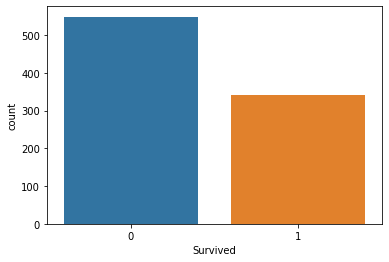

In [14]:
print("Plot For Survived and Dead")
print("Survived Key\n------------")
print("0 -> No\n1 -> Yes")
sns.countplot(train["Survived"])

In [15]:
print("Number of Male and Female")
train.Sex.value_counts()

Number of Male and Female


male      577
female    314
Name: Sex, dtype: int64

<AxesSubplot:xlabel='Sex', ylabel='count'>

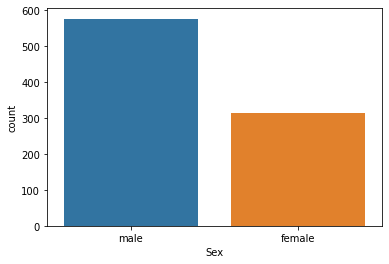

In [16]:
sns.countplot(train["Sex"])

In [17]:
print("Number of Passenger Class Wise")
train.Pclass.value_counts()

Number of Passenger Class Wise


3    491
1    216
2    184
Name: Pclass, dtype: int64

Plot Class Wise Passengers


<AxesSubplot:xlabel='Pclass', ylabel='count'>

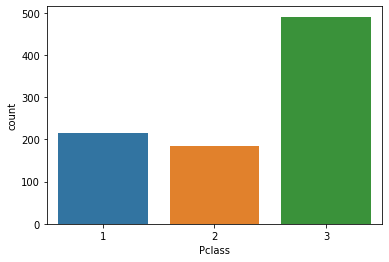

In [18]:
print("Plot Class Wise Passengers")
sns.countplot(train["Pclass"])

Sex Wise Survival
Survived Key
------------
0 -> No
1 -> Yes


<AxesSubplot:xlabel='Sex', ylabel='count'>

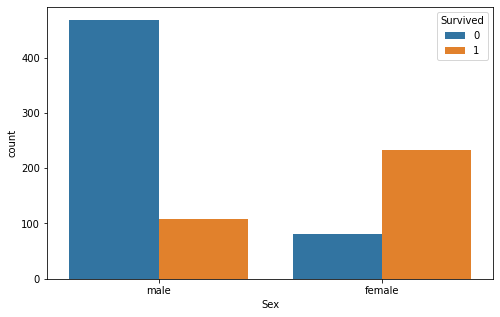

In [19]:
print("Sex Wise Survival")
print("Survived Key\n------------")
print("0 -> No\n1 -> Yes")
plt.figure(figsize=[8,5])
sns.countplot(x="Sex",hue="Survived",data=train)

Class Wise Passenger Survival
Survived Key
------------
0 -> No
1 -> Yes
--------------------------
Pessenger Ticket Class Key
--------------------------
1 -> 1st Class
2 -> 2nd Class
3 -> 3rd Class


<AxesSubplot:xlabel='Pclass', ylabel='count'>

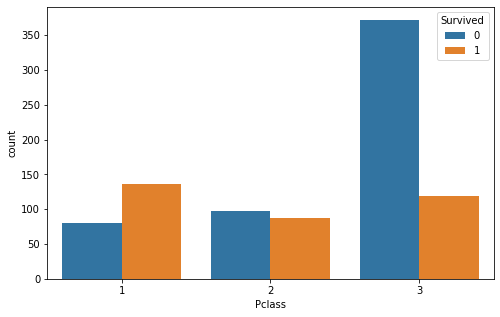

In [20]:
print("Class Wise Passenger Survival")
print("Survived Key\n------------")
print("0 -> No\n1 -> Yes")
print("--------------------------\nPessenger Ticket Class Key\n--------------------------")
print("1 -> 1st Class\n2 -> 2nd Class\n3 -> 3rd Class")

plt.figure(figsize=[8,5])
sns.countplot(x="Pclass",hue="Survived",data=train)

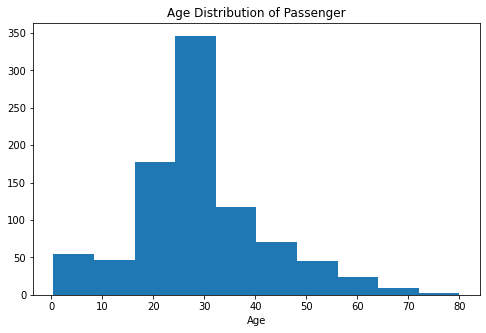

In [21]:
plt.figure(figsize=(8,5))
plt.hist(train['Age'])
plt.title('Age Distribution of Passenger')
plt.xlabel('Age')
plt.show()

<AxesSubplot:title={'center':'Number of Passenger Age Wise'}, xlabel='Age', ylabel='count'>

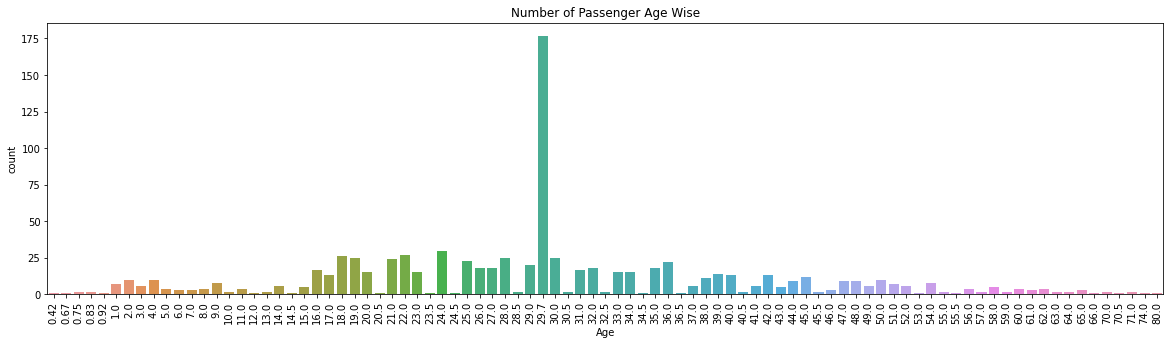

In [22]:
plt.figure(figsize=[20,5])
plt.title('Number of Passenger Age Wise')
plt.xticks(rotation=90)
sns.countplot(x="Age",data=train)

Survived Key
------------
0 -> No
1 -> Yes


<AxesSubplot:title={'center':'Number of Passenger Age Wise Servival'}, xlabel='Age', ylabel='count'>

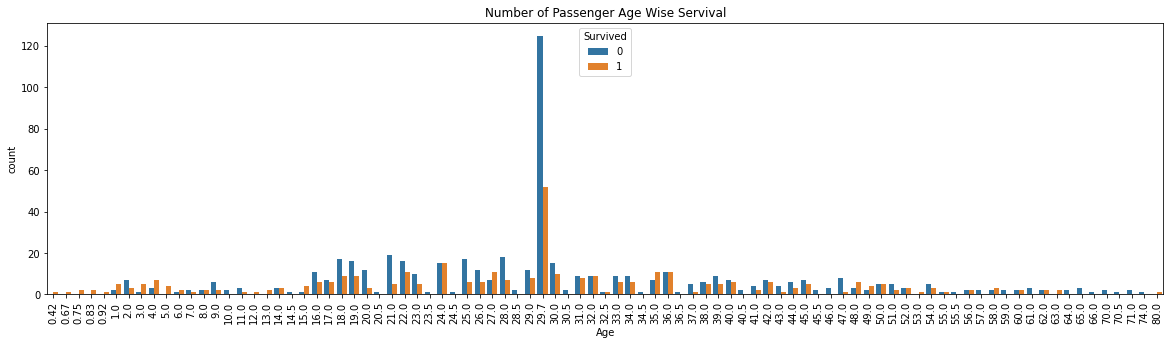

In [23]:
print("Survived Key\n------------")
print("0 -> No\n1 -> Yes")

plt.figure(figsize=[20,5])
plt.title('Number of Passenger Age Wise Servival')
plt.xticks(rotation=90)
sns.countplot(x="Age",hue="Survived",data=train)

<AxesSubplot:title={'center':'First 50 Passenger Servival Age Wise'}, xlabel='Age', ylabel='count'>

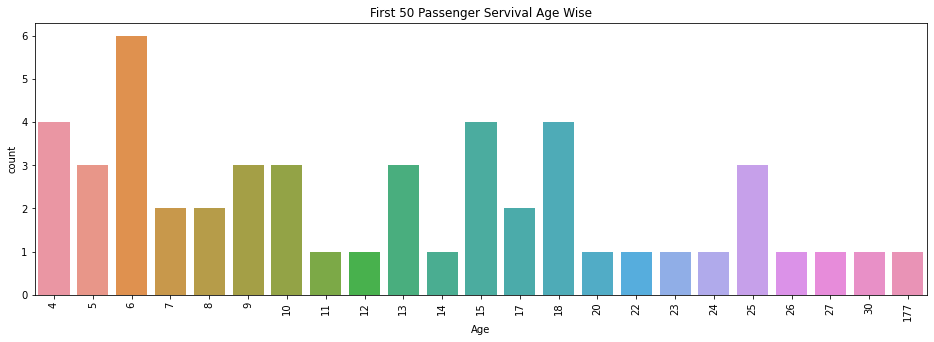

In [24]:
getAge = train.Age.value_counts().head(50)
plt.figure(figsize=[16,5])
plt.title('First 50 Passenger Servival Age Wise')
plt.xticks(rotation=90)
sns.countplot(x=getAge,data=train)

<AxesSubplot:title={'center':'First 50 Passenger Servival Age Wise'}, xlabel='Age', ylabel='count'>

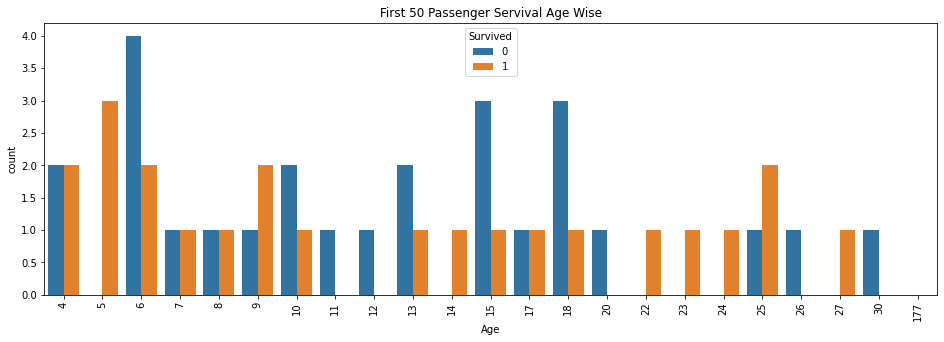

In [25]:
plt.figure(figsize=[16,5])
plt.title('First 50 Passenger Servival Age Wise')
plt.xticks(rotation=90)
sns.countplot(x=getAge,hue="Survived",data=train)

In [26]:
print("Missing/Null Values in Age: ",train.Age.isnull().sum())
print("Missing/Null Values in Survived: ",train.Survived.isnull().sum())

Missing/Null Values in Age:  0
Missing/Null Values in Survived:  0


In [27]:
xTrainVal = train[['Age']]
yTrainVal = train[['Survived']]

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
dtc = DecisionTreeClassifier()
dtc.fit(xTrainVal, yTrainVal)

DecisionTreeClassifier()

In [30]:
yTrainPred = dtc.predict(xTrainVal)
yTrainPred

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [31]:
test['Age'].isnull().sum()

86

In [32]:
print("Calculate the Test Mean/Average of Age")
meanTestAge = round(test.Age.mean(), 2)
print("Test Age Mean:", meanTestAge)

Calculate the Test Mean/Average of Age
Test Age Mean: 30.27


In [33]:
# Filling in Test Age with Calculated Mean/Average
test.Age.fillna(meanTestAge, axis=0, inplace=True)
test['Age'].isna().sum()

0

In [34]:
xTestVal = test[['Age']]
xTestVal

,Age
0,34.50
1,47.00
2,62.00
3,27.00
4,22.00
...,...
413,30.27
414,39.00
415,38.50
416,30.27


In [35]:
xTestPred = dtc.predict(xTestVal)
xTestPred

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [36]:
pred = pd.DataFrame(xTestPred,columns=['pred'])
pred.head()

,pred
0,0
1,0
2,0
3,1
4,0


In [37]:
from sklearn.metrics import classification_report,confusion_matrix

In [38]:
confusion_matrix(train['Survived'],yTrainPred)

array([[520,  29],
       [266,  76]])

In [39]:
gender_sub.columns

Index(['PassengerId', 'Survived'], dtype='object')

In [40]:
pred_compare = gender_sub.copy()
pred_compare['predictions'] = xTestPred
#pd.set_option('display.max_rows', None)
pred_compare.tail()

,PassengerId,Survived,predictions
413,1305,0,0
414,1306,1,0
415,1307,0,0
416,1308,0,0
417,1309,0,0


In [41]:
final_result = pd.DataFrame(confusion_matrix(pred_compare['Survived'],xTestPred),index=[['actual No','actual Yes']],columns=[['predicted No','predicted Yes']])
final_result

,predicted No,predicted Yes
actual No,239,27
actual Yes,129,23


In [42]:
classification_report(pred_compare['Survived'],xTestPred)

'              precision    recall  f1-score   support\n\n           0       0.65      0.90      0.75       266\n           1       0.46      0.15      0.23       152\n\n    accuracy                           0.63       418\n   macro avg       0.55      0.52      0.49       418\nweighted avg       0.58      0.63      0.56       418\n'